In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Fonctions

In [ ]:
# Paramètres
f = 0.005 # 5mm
lambda_0 = 600e-9 # 600nm
nt = 1.0
k0 = (2 * np.pi)/(lambda_0)
kt = (2 * np.pi * nt) / lambda_0
R_pupille = 0.004 # 4mm
NA = R_pupille/f

# Grilles
N = 250
z_min = -3000e-6
z_max = 3000e-6
x = np.linspace(-R_pupille, R_pupille, 2 * N)
y = np.linspace(-R_pupille, R_pupille, 2 * N)
z = np.linspace(z_min, z_max, 2 * N)
z_micro = z * 1e6
X, Y = np.meshgrid(x, y)
Rp = np.sqrt(X**2 + Y**2)

# Fonctions
def compute_E(E_t, theta, z):
  # Calcule le champs après l'objectif du microscope
  A = -(1j * f)/(lambda_0 * kt**2)
  cos_theta = np.cos(theta)
  kz = kt * cos_theta

  E_apres = np.zeros((len(x), len(y), len(z)), dtype = complex)

  for i in range(len(z)):
    exp = f_exp(kz, z[i])

    E_3D = (E_t * exp) / cos_theta
    E_apres[:, :, i] = np.fft.fftshift(np.fft.fft2(E_3D))

  return A * E_apres

def theta_field(X, Y, R, NA):
  # Construit la grille des theta
  r = np.sqrt(X**2 + Y**2)
  a = (r/R) * (NA/nt)
  a = np.clip(a, 0, 1)
  return np.arcsin(a)

def f_exp(kz, z):
  return np.exp(1j * kz * z)

def Plot_output(field_phase): #Plot les graph apres etre passé dans l'objectif de microscope (plot les 3 coupes transversales)
  # Plot du champs après
  plt.figure()
  fig, axes = plt.subplots(1, 3, figsize=(12, 4))
  mid = [s//2 for s in field_phase.shape]
  plt.suptitle('Coupes transversales')
  axes[0].imshow(field_phase[mid[0], :, :], cmap='viridis')
  axes[1].imshow(field_phase[:, mid[1], :], cmap='viridis')
  axes[2].imshow(field_phase[:, :, mid[2]], cmap='viridis')
  axes[0].set_title('Coupe YZ')
  axes[1].set_title('Coupe XZ')
  axes[2].set_title('Coupe XY')
  plt.tight_layout()

def Plot_input(E_t): # Plot l'amplitude et la phase de l'image dans la pupille d'entré
  # Plot le champs en entré
  Et_ampl = np.abs(E_t)
  Et_arg = np.angle(E_t)
  plt.figure()
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))
  mid = [s//2 for s in E_t.shape]
  plt.suptitle('Coupes transversales')
  axes[0].imshow(Et_ampl, cmap='viridis')
  axes[1].imshow(Et_arg, cmap='viridis')
  axes[0].set_title('Amplitude du champs')
  axes[1].set_title('Phase du champs')
  plt.tight_layout()
  plt.show()

theta = theta_field(X, Y, R_pupille, NA) # Grille des theta

def Plotfaisceau(E_apres):
  # Récupère les indices du tableau 3D des bords du faisceau
  field = np.abs(E_apres)
  mid = [s//2 for s in field.shape]
  upper_yz = np.zeros(len(z))
  lower_yz = np.zeros(len(z))
  #seuil = 0.5 * np.max(field[mid[0], :, :])

  for i in range(len(z)): # Dans le plan yz
    idx_max = N
    idx_min = 0
    seuil = (1/2) * np.max(field[mid[0], :, i]) # Seuil par rapport au pixel d'intensité max de la colonne

    for j in range(len(y)): # Recherche du pixel de la partie supérieur du faisceau
      if (field[mid[0], len(y) - j - 1, i] > seuil):
        idx_max = len(y) - j - 1
        break

    for j in range(len(y)): # Recherche du pixel de la partie inferieur du faisceau
      if (field[mid[0], j, i] > seuil):
        idx_min = j
        break

    upper_yz[i] = idx_max
    lower_yz[i] = idx_min

  return upper_yz, lower_yz # Ne renvoie que pour l'un des plan car symétrie par rotation autour de l'axe z

def FWMH_zone(upper_yz, lower_yz):
  pixel_size_y = (2 * R_pupille)/(2 * N)
  demi_hauteur = (upper_yz - lower_yz) * pixel_size_y * 1e6

  seuil = 2 * (np.min(demi_hauteur))
  mid = len(demi_hauteur)//2

  idx_right = len(demi_hauteur)
  for i in range(mid):
    if (demi_hauteur[mid + i] >= seuil):
      idx_right = mid + i
      break

  idx_left = 0
  for i in range(mid):
    if (demi_hauteur[mid - i] >= seuil):
      idx_left = mid - i
      break

  plt.figure()
  plt.plot(z_micro, demi_hauteur, color = 'red')
  plt.xlabel('Axe des z (μm)')
  plt.ylabel('Demi-hauteur (μm)')
  plt.title('Evolution de la demi-hauteur du faisceay de Bessel')
  plt.show()
  pixel_size_z = (np.abs(z_min) + z_max)/(2 * N)
  zone = (idx_right - idx_left) * pixel_size_z
  return zone

# Bessel

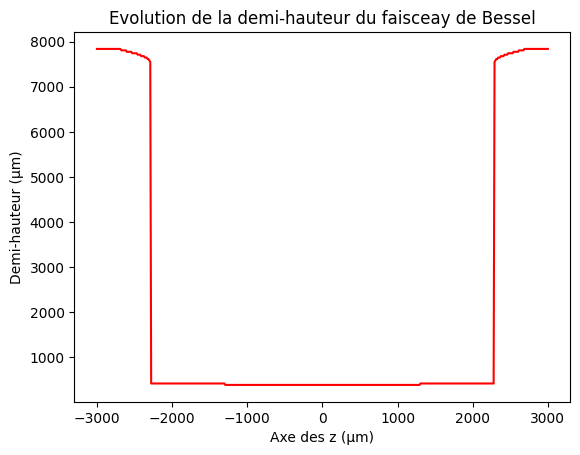

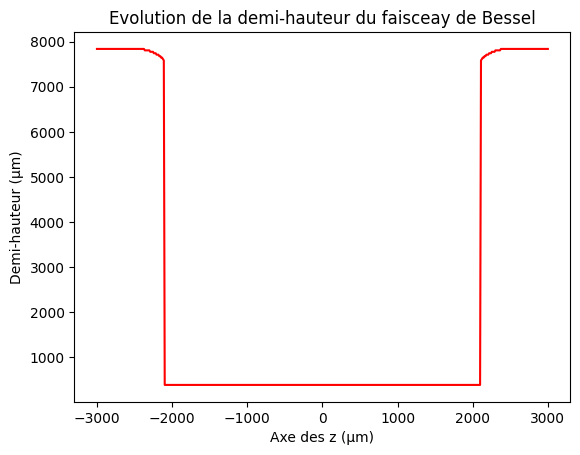

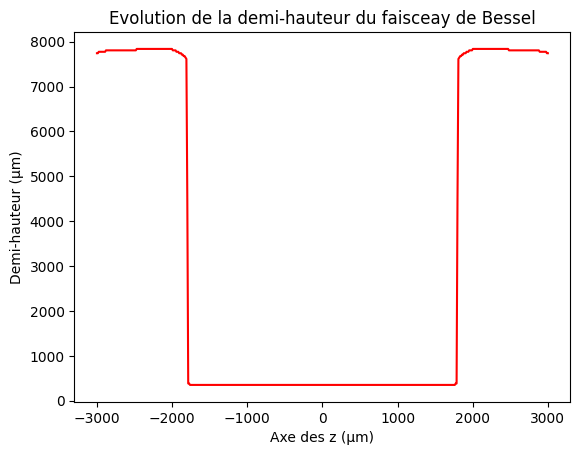

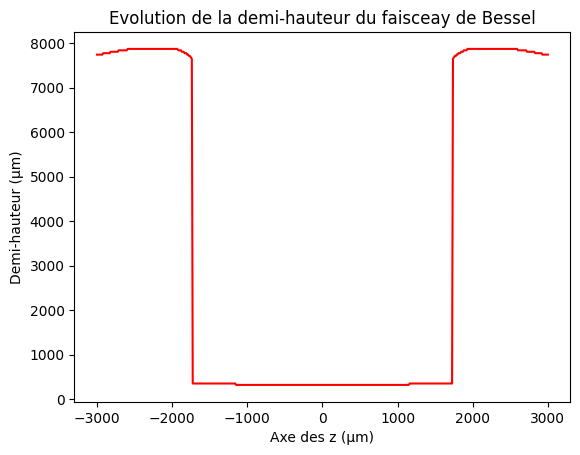

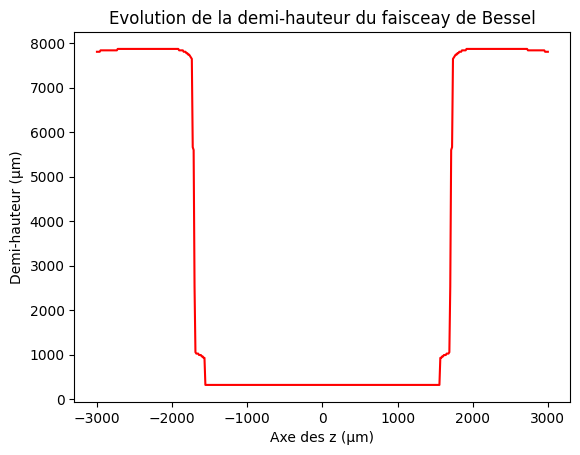

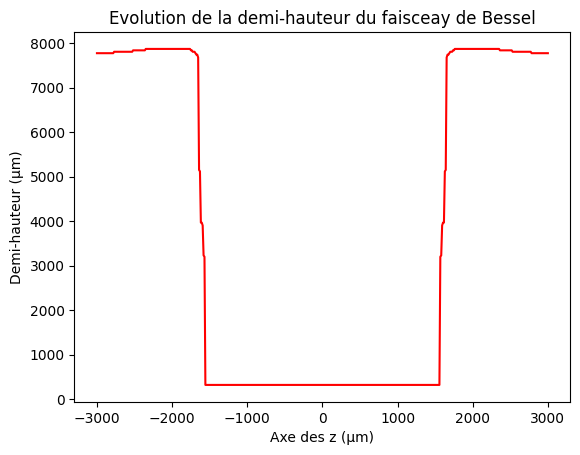

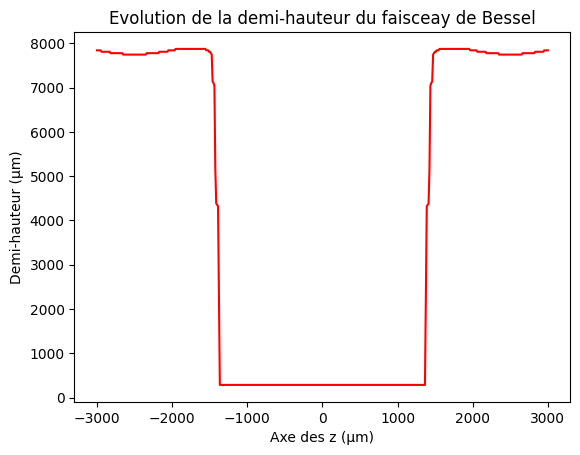

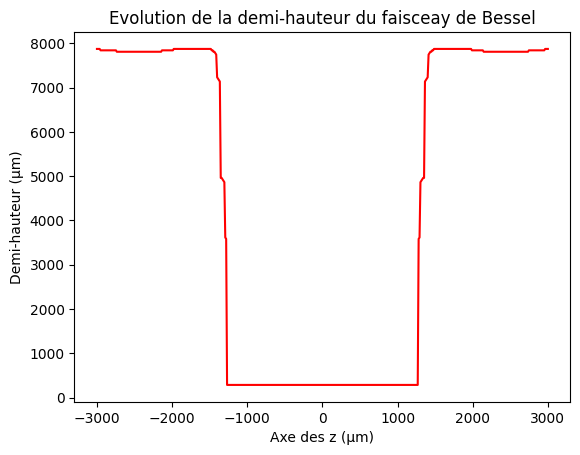

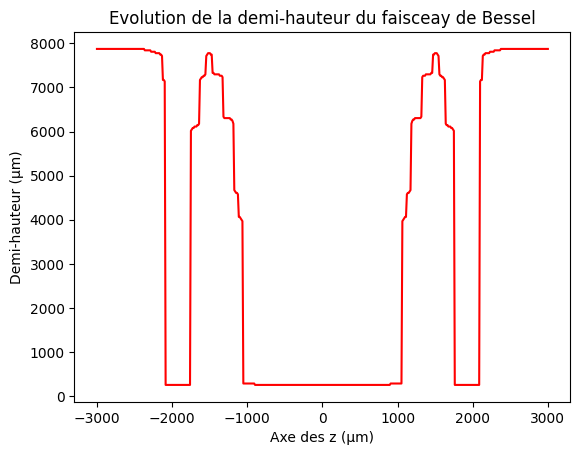

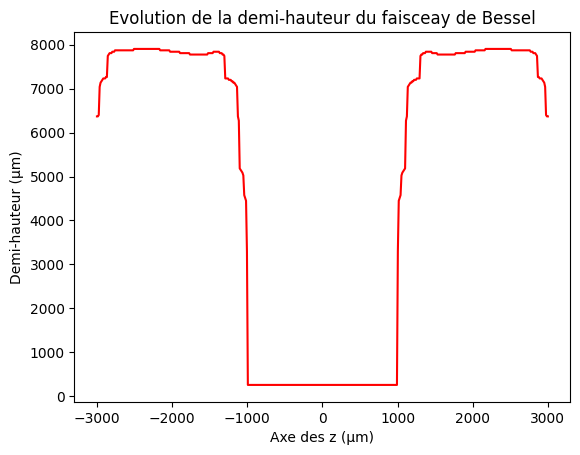

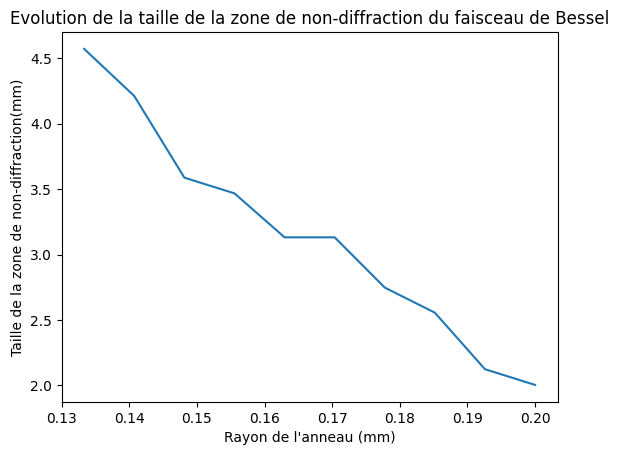

[np.float64(0.0045720000000000005), np.float64(0.0042120000000000005), np.float64(0.003588), np.float64(0.003468), np.float64(0.0031320000000000002), np.float64(0.0031320000000000002), np.float64(0.002748), np.float64(0.002556), np.float64(0.002124), np.float64(0.002004)]


In [ ]:
# Faisceau de Bessel

# Paramètres
#z = np.linspace(-1000e-6, 1000e-6, 500)
#z_micro = z * 1e6
center_x = N//2
center_y = N//2

R = np.linspace(R_pupille/30, R_pupille/20, 10)
#pixel_size = (np.abs(z_min) + z_max)/(2 * N)
zone_list = []
for Ri in R:
  Et_Bessel = np.zeros((len(x), len(y)))
  dr = Ri/4

  Et_Bessel[ (Rp >= Ri) & (Rp <= Ri + dr) ] = 1

  E_Bessel = compute_E(Et_Bessel, theta, z) # Champs après du cercle
  upper_yz, lower_yz = Plotfaisceau(E_Bessel)
  zone_size = FWMH_zone(upper_yz, lower_yz)
  zone_list.append(zone_size)

  # Plot du champs original
  #plt.figure()
  #plt.imshow(Et_Bessel, cmap='viridis', origin='lower')
  #plt.title('Champs original (dernier anneau généré)')
  #plt.colorbar()
  #plt.show()

R_mm = R * 1e3
zone = np.array(zone_list) * 1e3
plt.figure()
plt.plot(R_mm, zone)
plt.xlabel("Rayon de l'anneau (mm)")
plt.ylabel('Taille de la zone de non-diffraction(mm)')
plt.title('Evolution de la taille de la zone de non-diffraction du faisceau de Bessel') # seuil fixé arbitrairement à 2 fois la FWHM minimale (au plan focal)
plt.show()
print(zone_list)